# Choropleth Murder Maps (Pre/Post-2017)

This notebook overlays gun-homicide point density on Chicago community-area boundaries together with a street network, then compares the most-violent neighborhoods in the pre-ShotSpotter and ShotSpotter periods. The ShotSpotter cutoff is 2017-01-13 and the study window ends 2023-12-31.

*Note: this is an exploratory mapping notebook. The canonical analysis and all published figures live in the `scripts/` directory.*

In [1]:
import geopandas as gpd
from shapely import wkt
import pandas as pd
import matplotlib.pyplot as plt

## Load the boundary, street, and homicide data

Community-area polygons and the street network come from the raw City of Chicago files; the cleaned six-neighborhood homicide subset is read from `data/processed/`.

In [2]:
gdf = gpd.read_file("../data/raw/CommAreas_20250408.geojson")
streets = pd.read_csv("../data/raw/transportation_20250415.csv")
homicide = pd.read_csv("../data/processed/Homicide_six_hoods.csv")

## Define the choropleth plotting function

`plot_chicago_neighborhoods` ranks community areas by homicide count over a given date range, shades and numbers the most-violent areas, and adds the street network, a north arrow, a scale bar, and a ranked legend.

In [3]:
def plot_chicago_neighborhoods(homicide_data, streets_data, gdf, start_date, end_date):
    streets_data["geometry"] = streets_data["the_geom"].apply(wkt.loads)
    streets_gdf = gpd.GeoDataFrame(streets_data, geometry="geometry", crs="EPSG:4326")
    streets_gdf = streets_gdf.to_crs(gdf.crs)

    filtered_homicide_data = homicide_data[
        (homicide_data["Date"] >= start_date) & 
        (homicide_data["Date"] <= end_date)
    ]
    
    annual_homicides = (
        filtered_homicide_data.groupby("Community")
        .size()
        .reset_index(name="Homicide Count")
    )

    annual_homicides["Rank"] = annual_homicides["Homicide Count"].rank(method="first", ascending=False).astype(int)
    selected_neighborhoods = dict(zip(annual_homicides["Community"].str.title(), annual_homicides["Rank"]))
    
    highlighted_gdf = gdf[gdf['community'].str.title().isin(selected_neighborhoods.keys())]

    xmin, ymin, xmax, ymax = gdf.total_bounds

    fig, ax = plt.subplots(figsize=(6, 8), dpi=300)
    ax.set_facecolor("#f0f0f0")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    gdf.plot(ax=ax, color="#e0e0e0", edgecolor="#4d4d4d", alpha=0.7, zorder=1)
    highlighted_gdf.plot(ax=ax, color="#ff6347", edgecolor="#4d4d4d", alpha=0.8, zorder=2)
    streets_gdf.plot(ax=ax, color="#1f78b4", linewidth=0.5, alpha=0.7, zorder=3)

    for idx, row in highlighted_gdf.iterrows():
        centroid = row.geometry.centroid
        neighborhood = row['community'].title()
        number = selected_neighborhoods.get(neighborhood)
        ax.text(centroid.x, centroid.y, str(number), fontsize=12, fontweight="bold", color="black", ha="center")

    plt.title(f"Chicago Most Violent Neighborhoods {start_date} - {end_date}", fontsize=16, weight="bold")
    plt.axis("off")

    ax.annotate("N", xy=(0.98, 0.95), xycoords="axes fraction", fontsize=12, fontweight="bold")
    ax.arrow(0.98, 0.94, 0, -0.05, head_width=0.02, head_length=0.04, fc="black", ec="black")

    import math
    meters_per_deg_lon = 111320 * math.cos(math.radians(41.85))
    bar_deg = 500 / meters_per_deg_lon  # 500m in degrees of longitude
    bar_x0 = xmin + (xmax - xmin) * 0.1
    bar_y0 = ymin + (ymax - ymin) * 0.05
    ax.plot([bar_x0, bar_x0 + bar_deg], [bar_y0, bar_y0], color='black', linewidth=2)
    ax.text(bar_x0 + bar_deg / 2, bar_y0 + (ymax - ymin) * 0.01, '500 m', fontsize=10, ha='center')

    sorted_neighborhoods = sorted(selected_neighborhoods.items(), key=lambda x: x[1], reverse=False)
    legend_labels = [f"{num}: {name}" for name, num in sorted_neighborhoods]
    legend_text = "\n".join(legend_labels)
    plt.annotate(legend_text, xy=(0.01, 0.02), xycoords="figure fraction", fontsize=10, ha="left", va="bottom")

    return fig

## Render the pre-2017, post-2017, and full-period maps

The function is called for the pre-ShotSpotter period, the ShotSpotter period, and the full study window so the maps can be compared side by side.

C:\Users\abelma2\AppData\Local\Temp\ipykernel_17576\3869376269.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_pre.show()
C:\Users\abelma2\AppData\Local\Temp\ipykernel_17576\3869376269.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_post.show()
C:\Users\abelma2\AppData\Local\Temp\ipykernel_17576\3869376269.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_full.show()


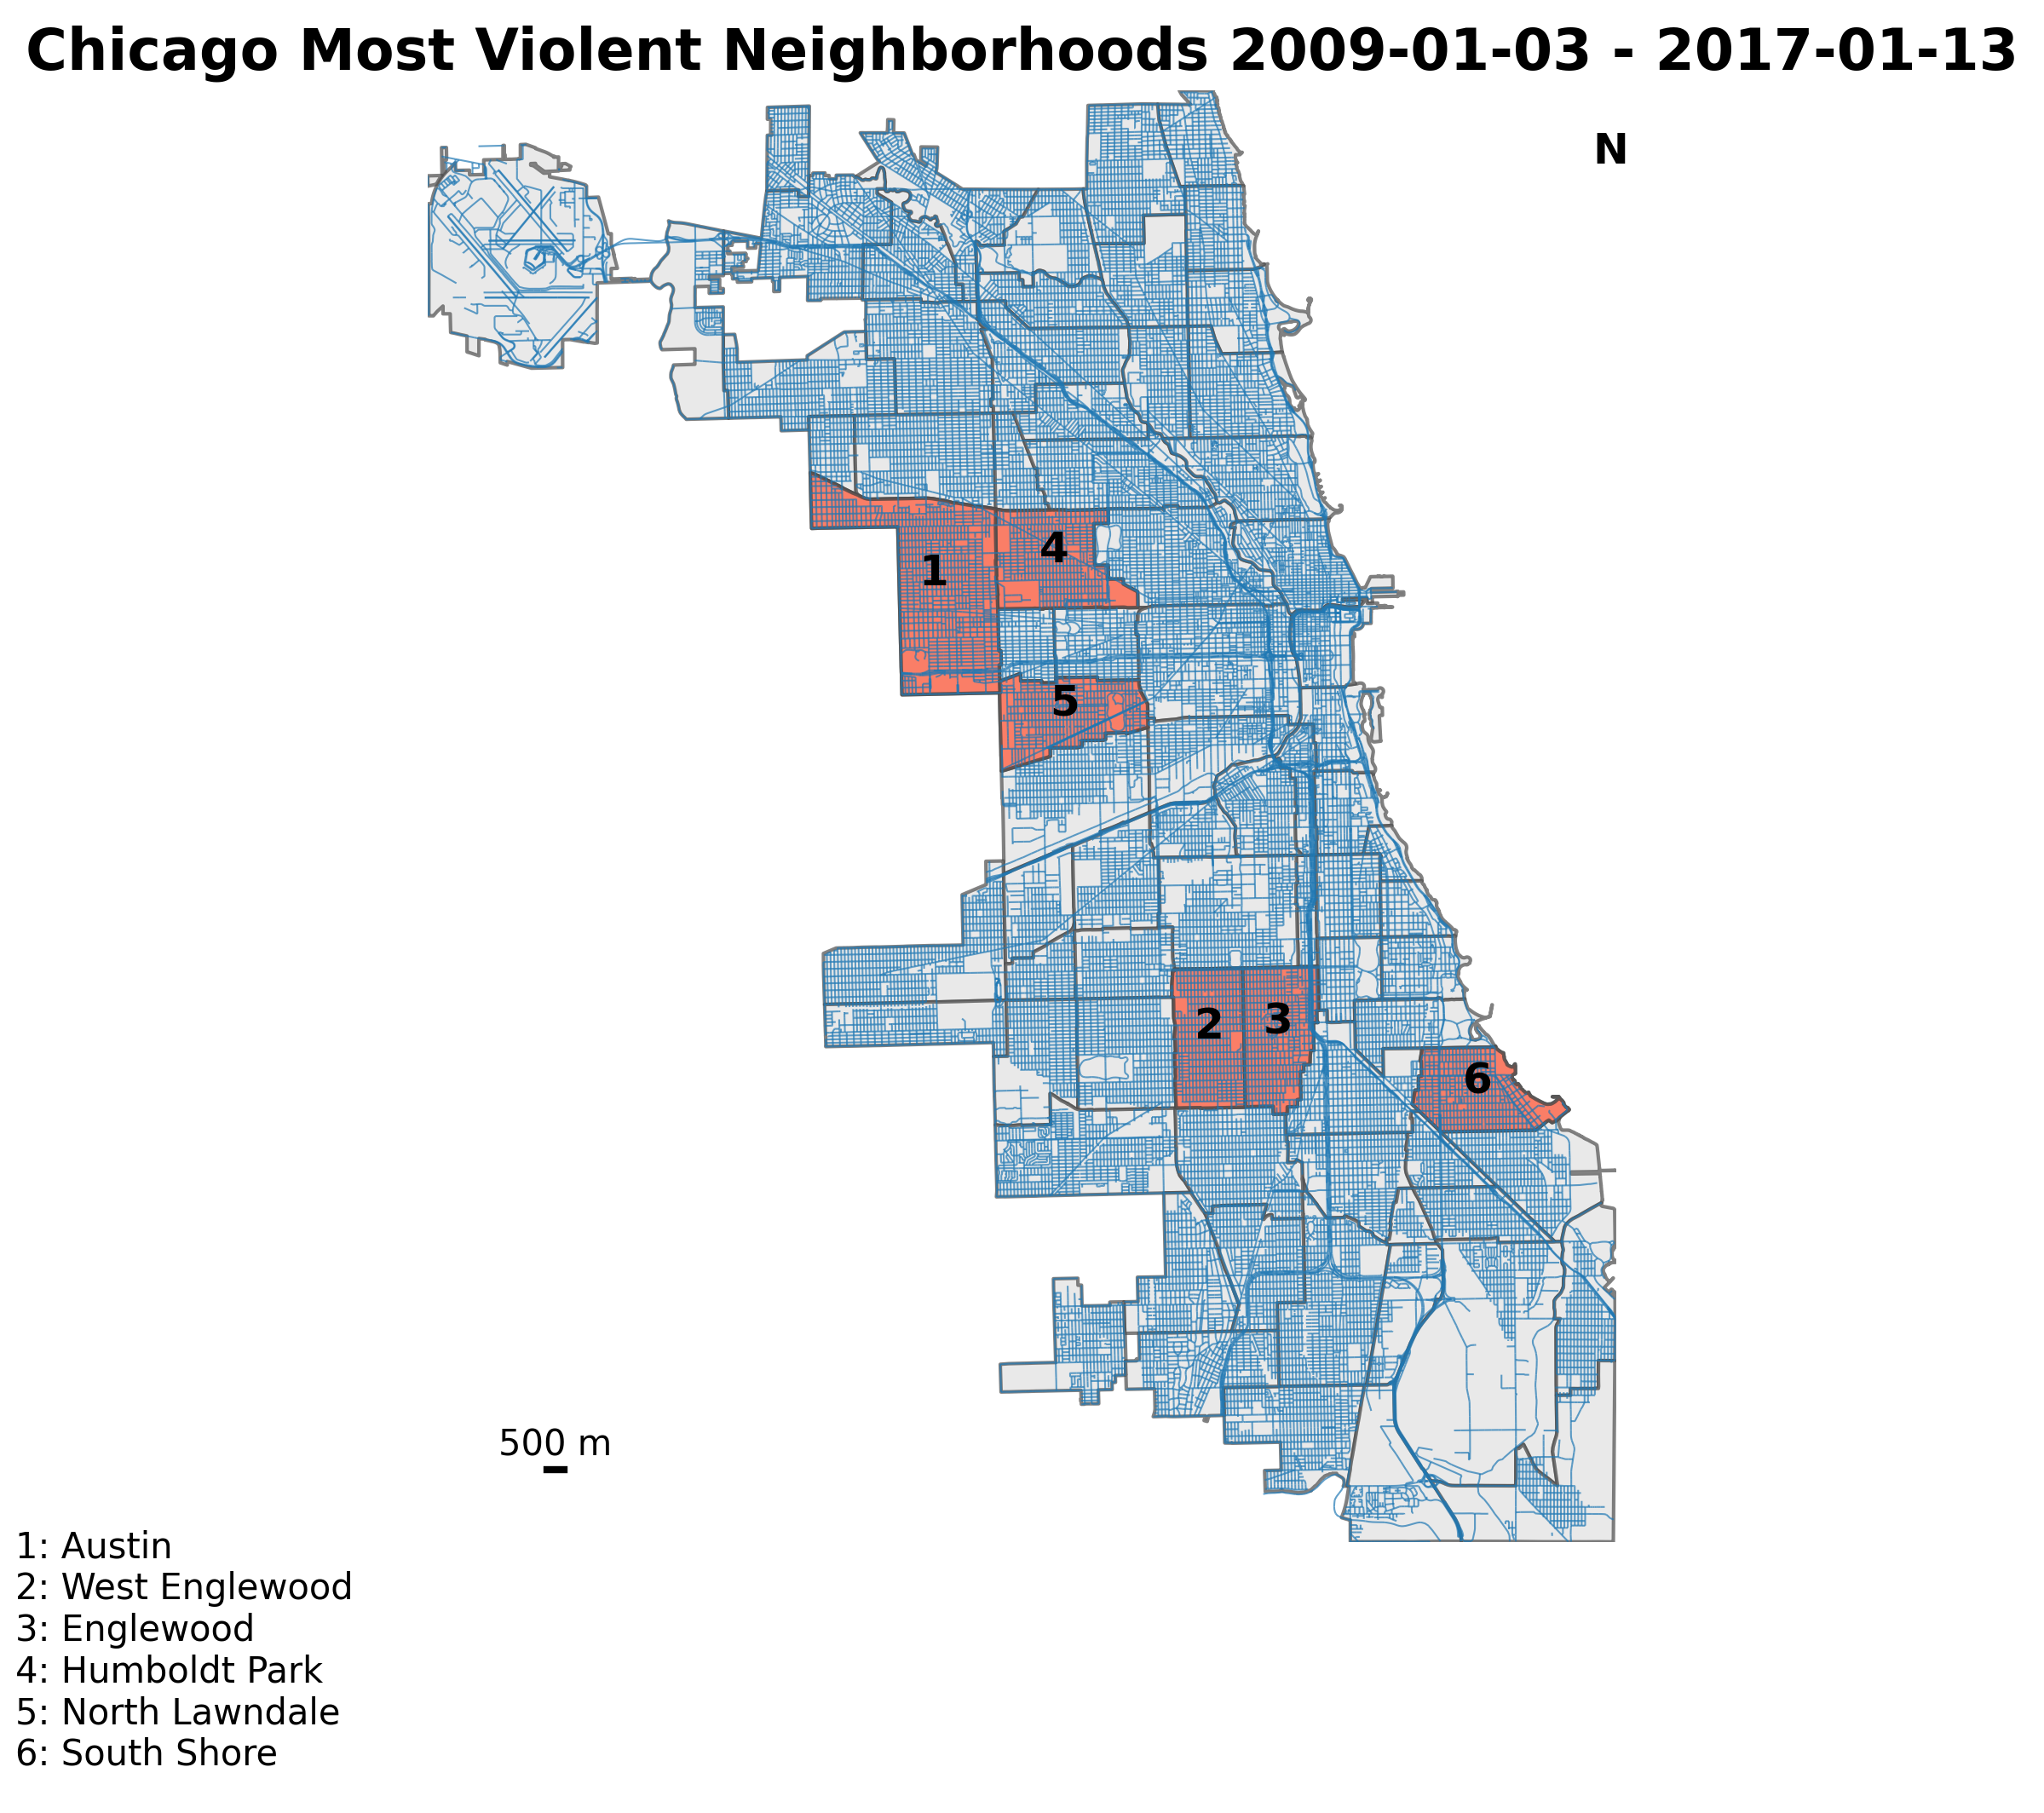

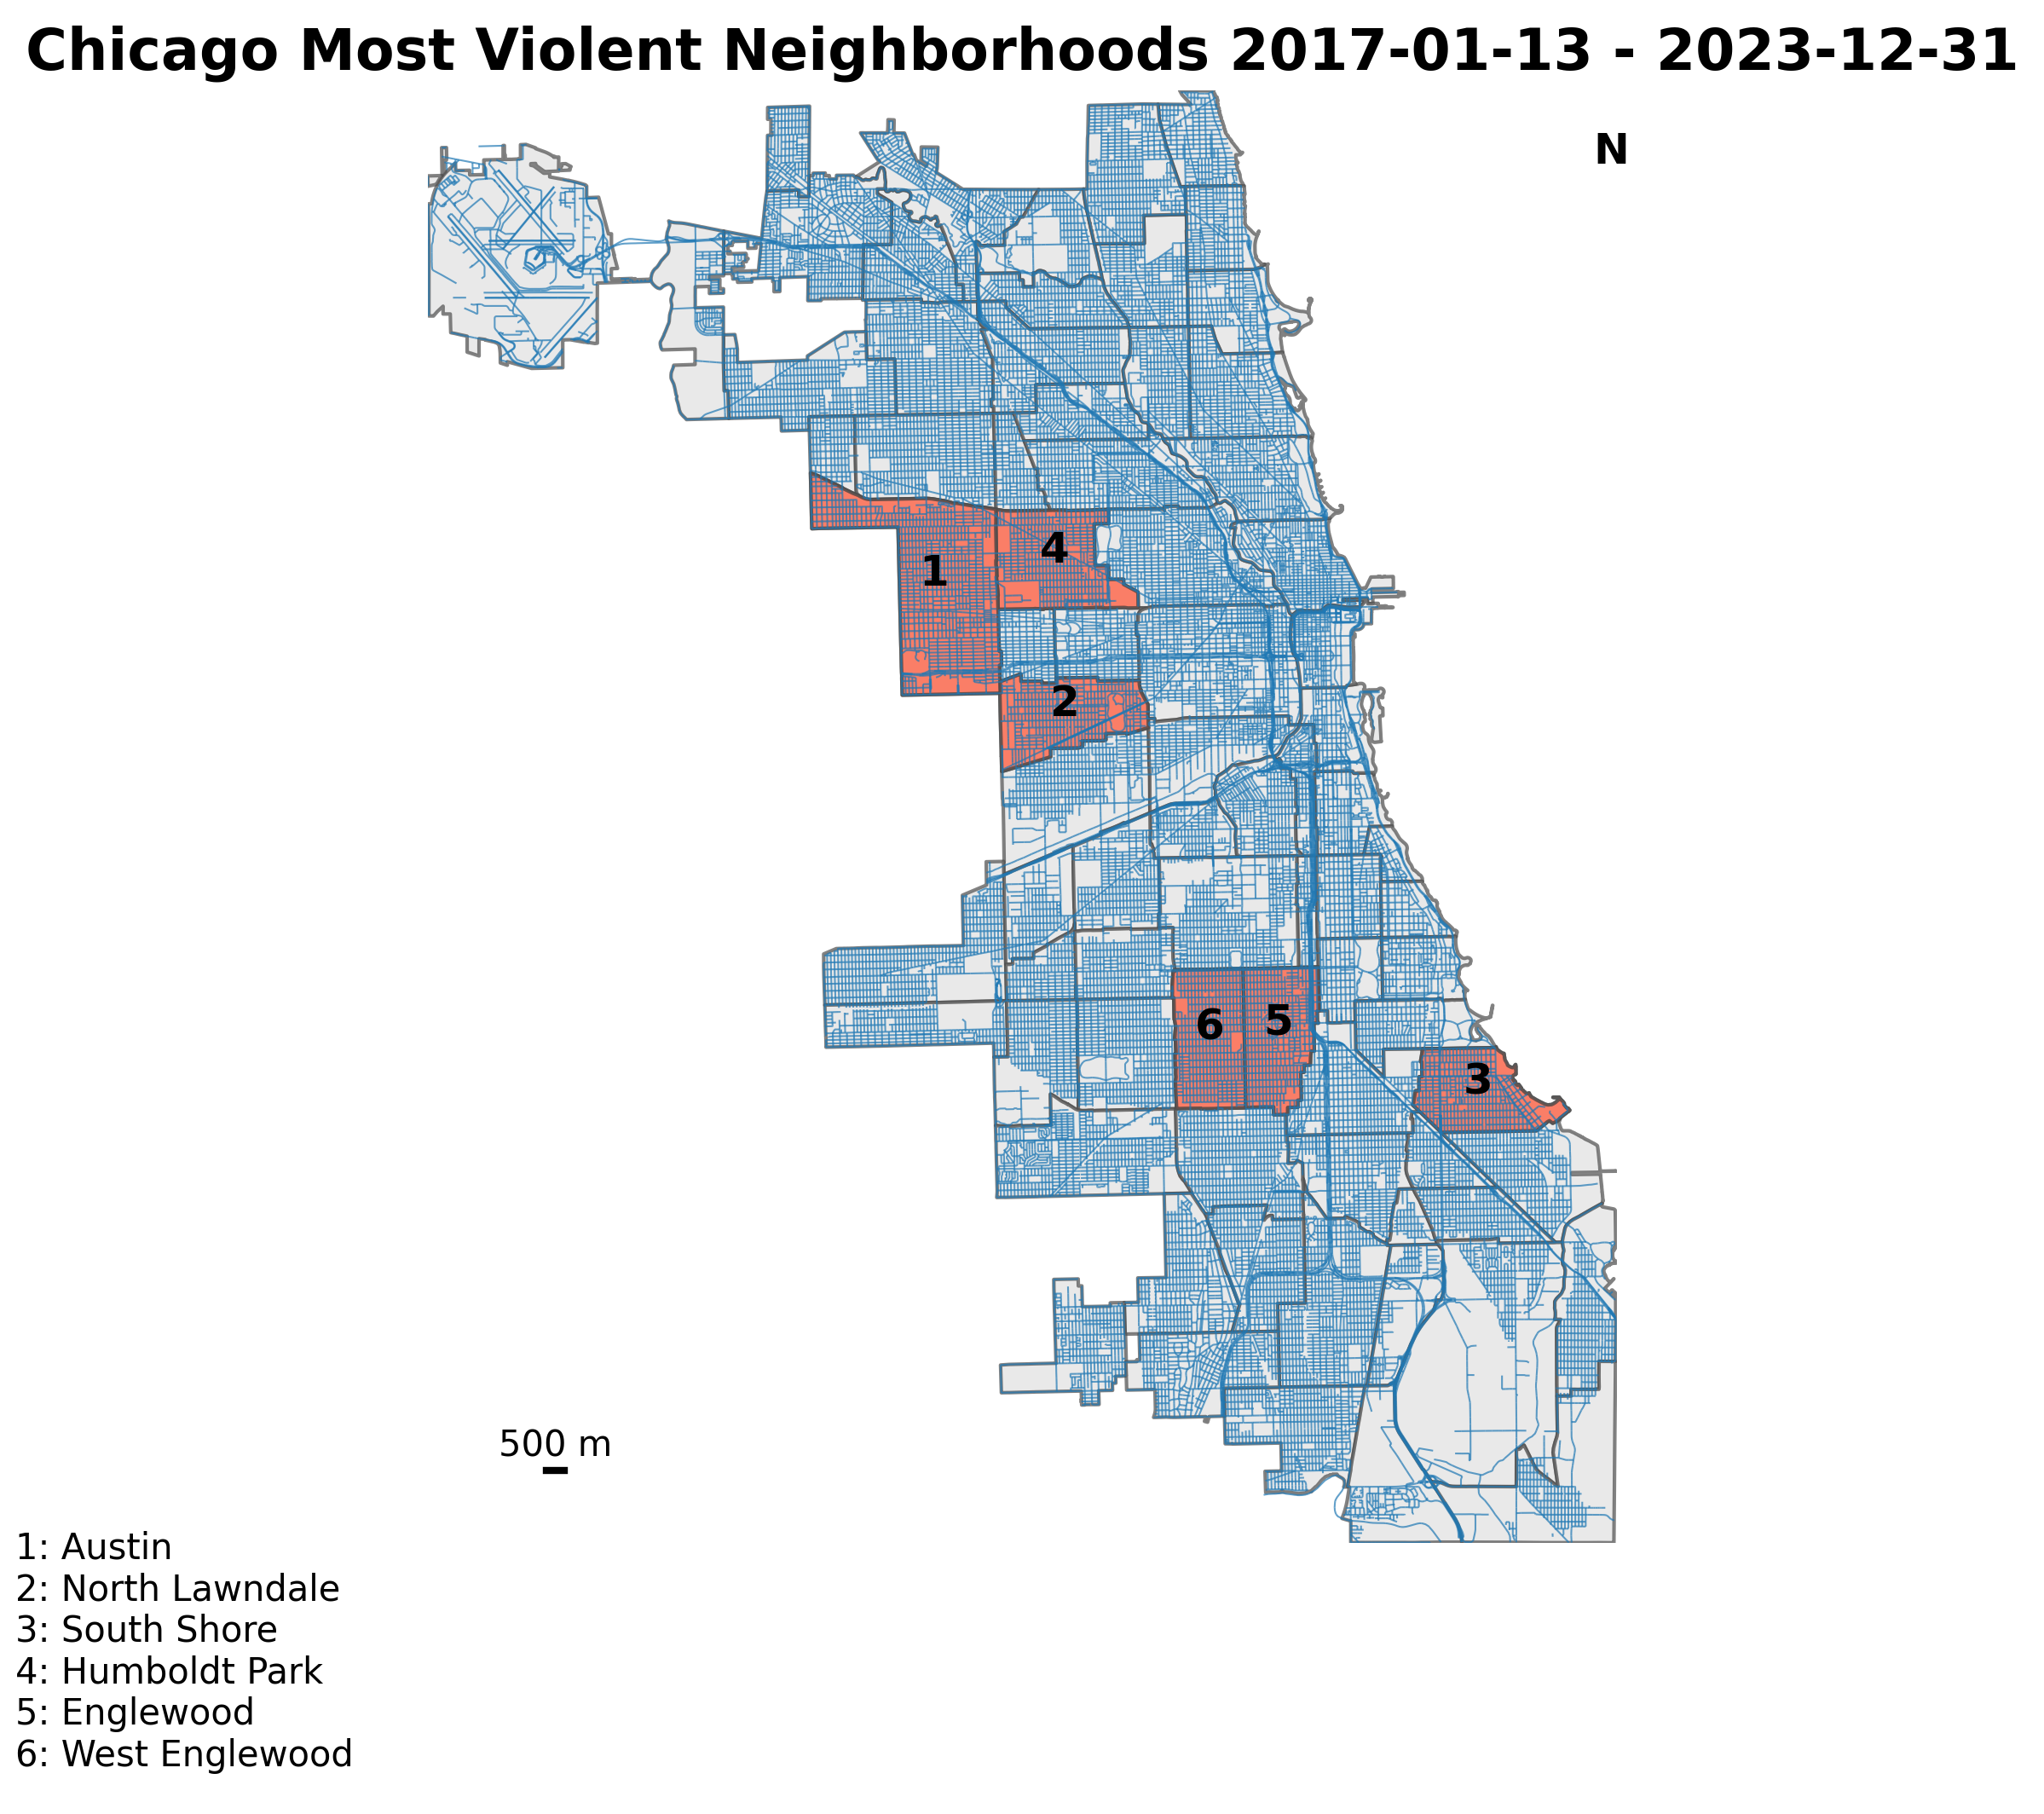

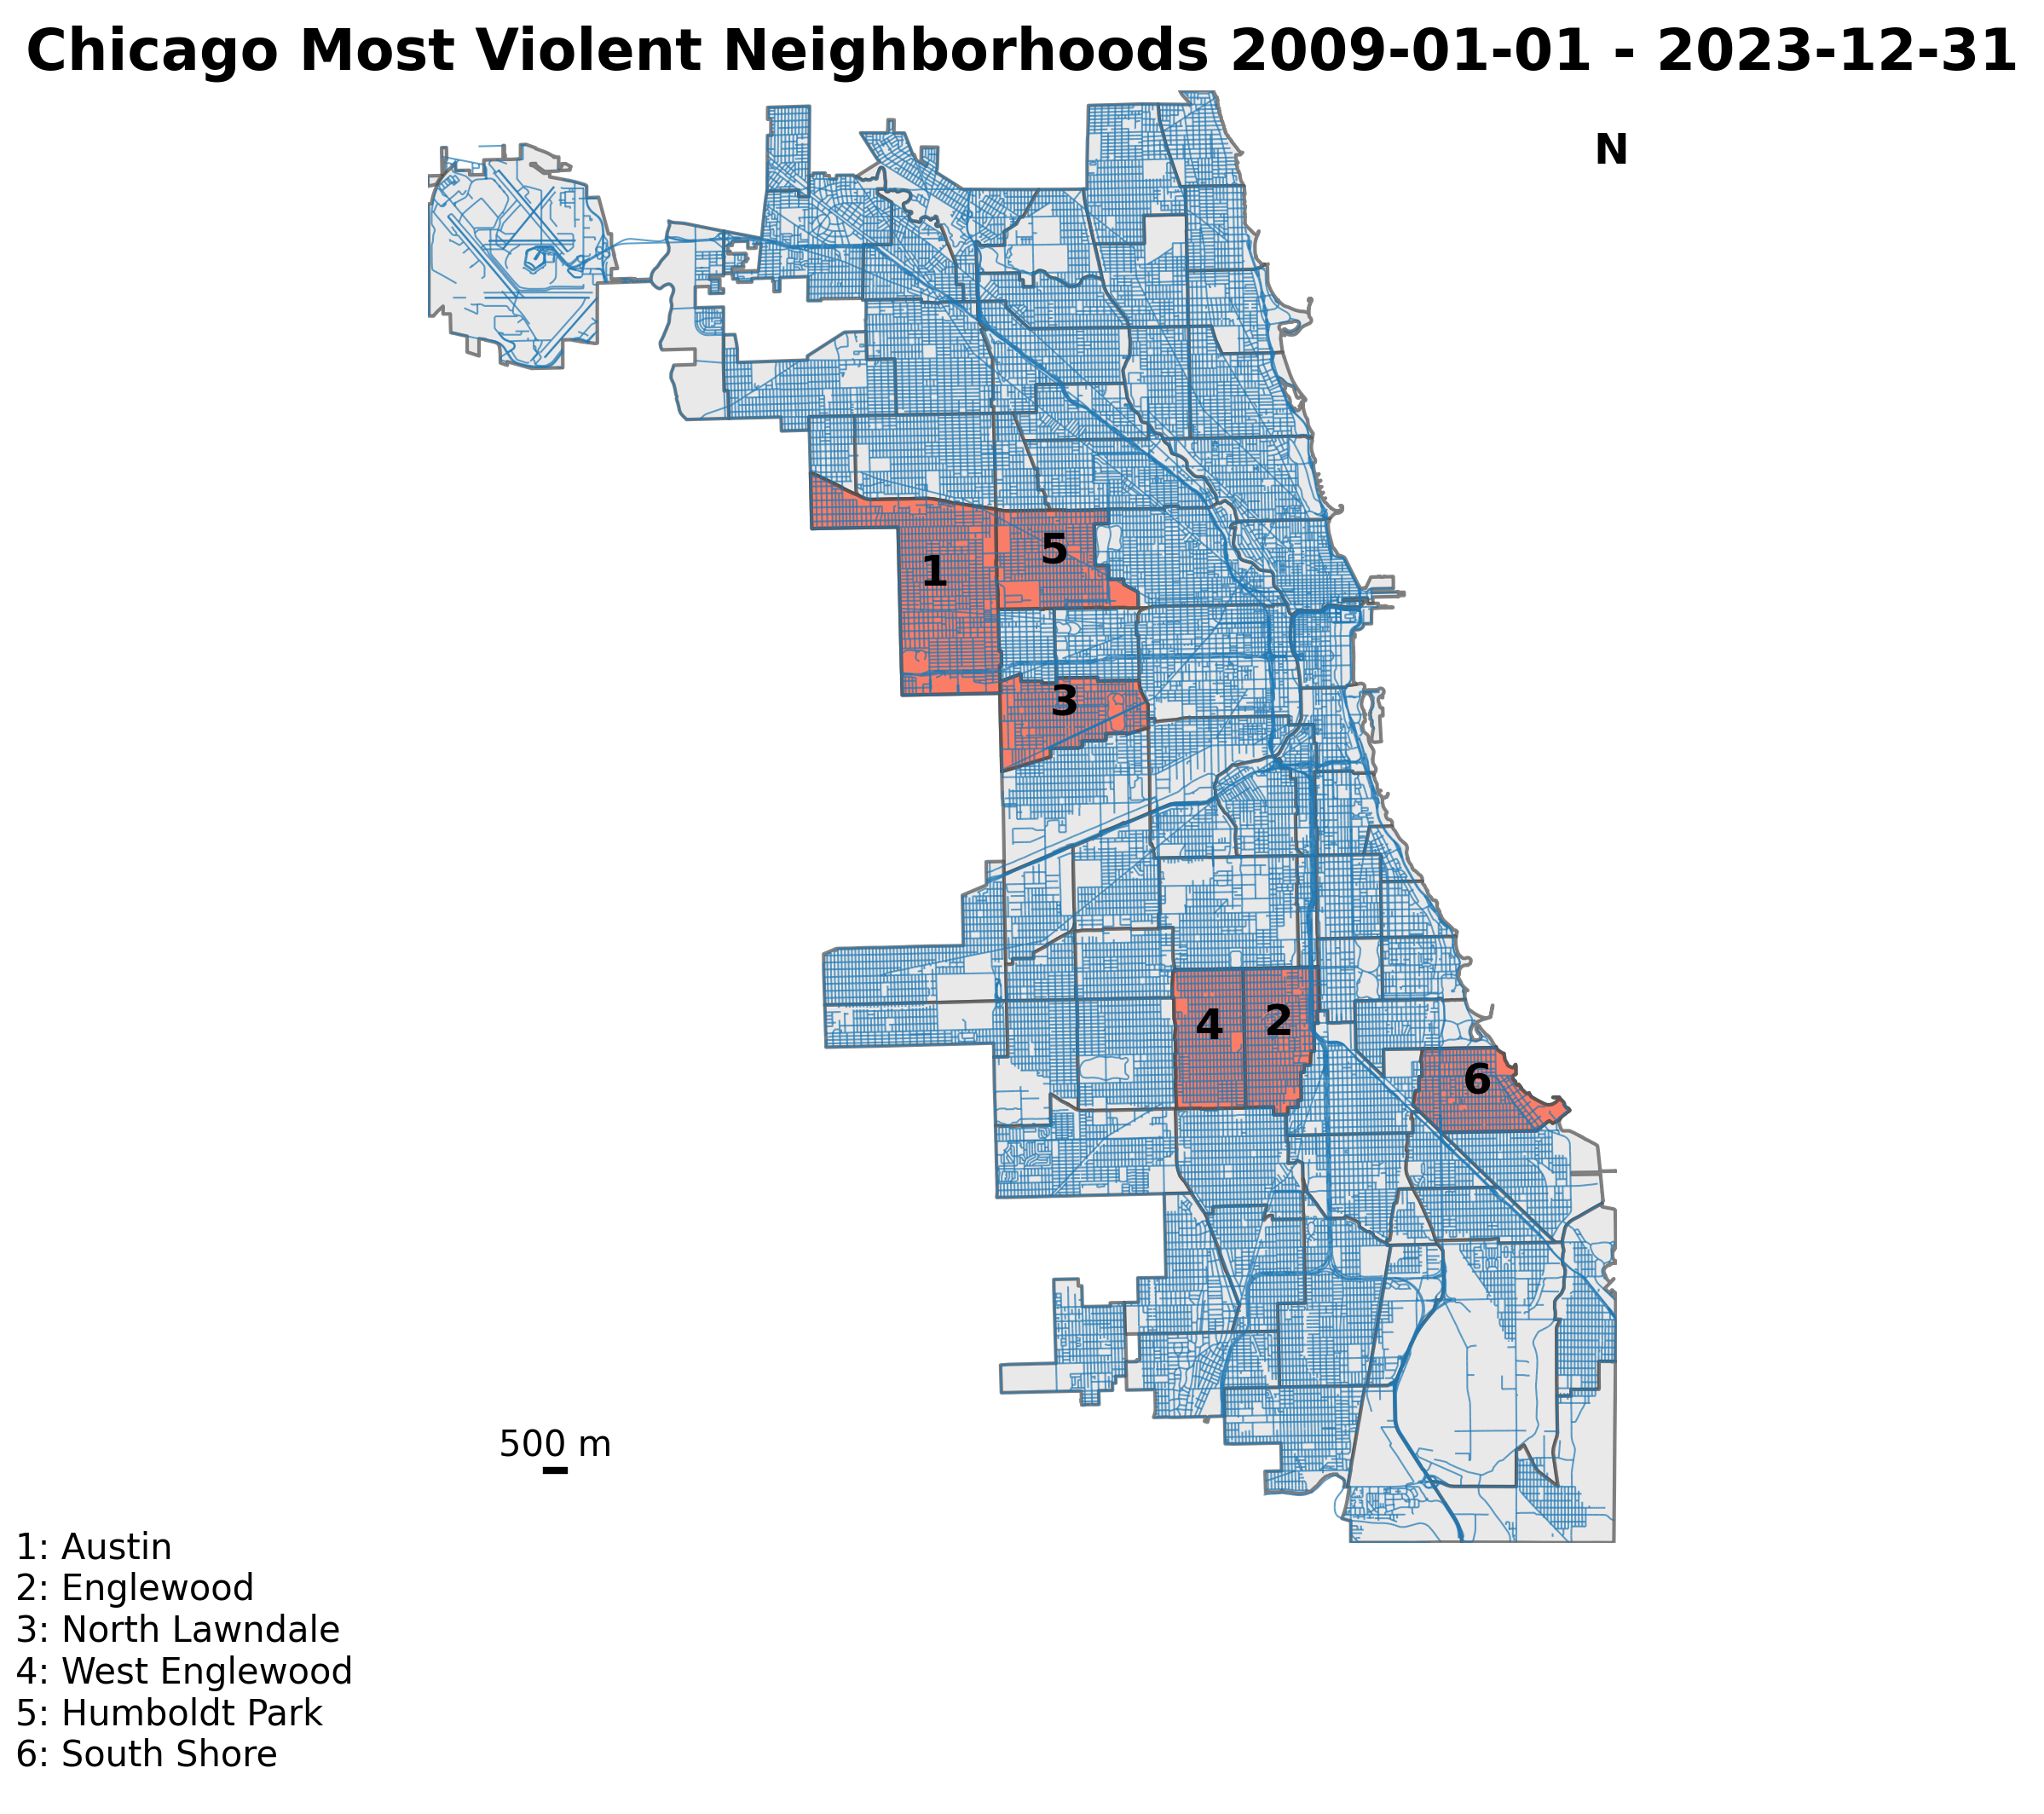

In [4]:
plot_pre  = plot_chicago_neighborhoods(homicide, streets, gdf, "2009-01-03", "2017-01-13")
plot_post = plot_chicago_neighborhoods(homicide, streets, gdf, "2017-01-13", "2023-12-31")
plot_full = plot_chicago_neighborhoods(homicide, streets, gdf, "2009-01-01", "2023-12-31")

plot_pre.show()
plot_post.show()
plot_full.show()